# 04 — Location Insights

Geographic distribution of IT jobs across German states and cities. Shows where hiring is concentrated, which cities dominate specific job families, and how remote work adoption varies by region.

In [13]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [14]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, heatmap, stacked_bar

df.head(3)

,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## Jobs by State (bar chart)

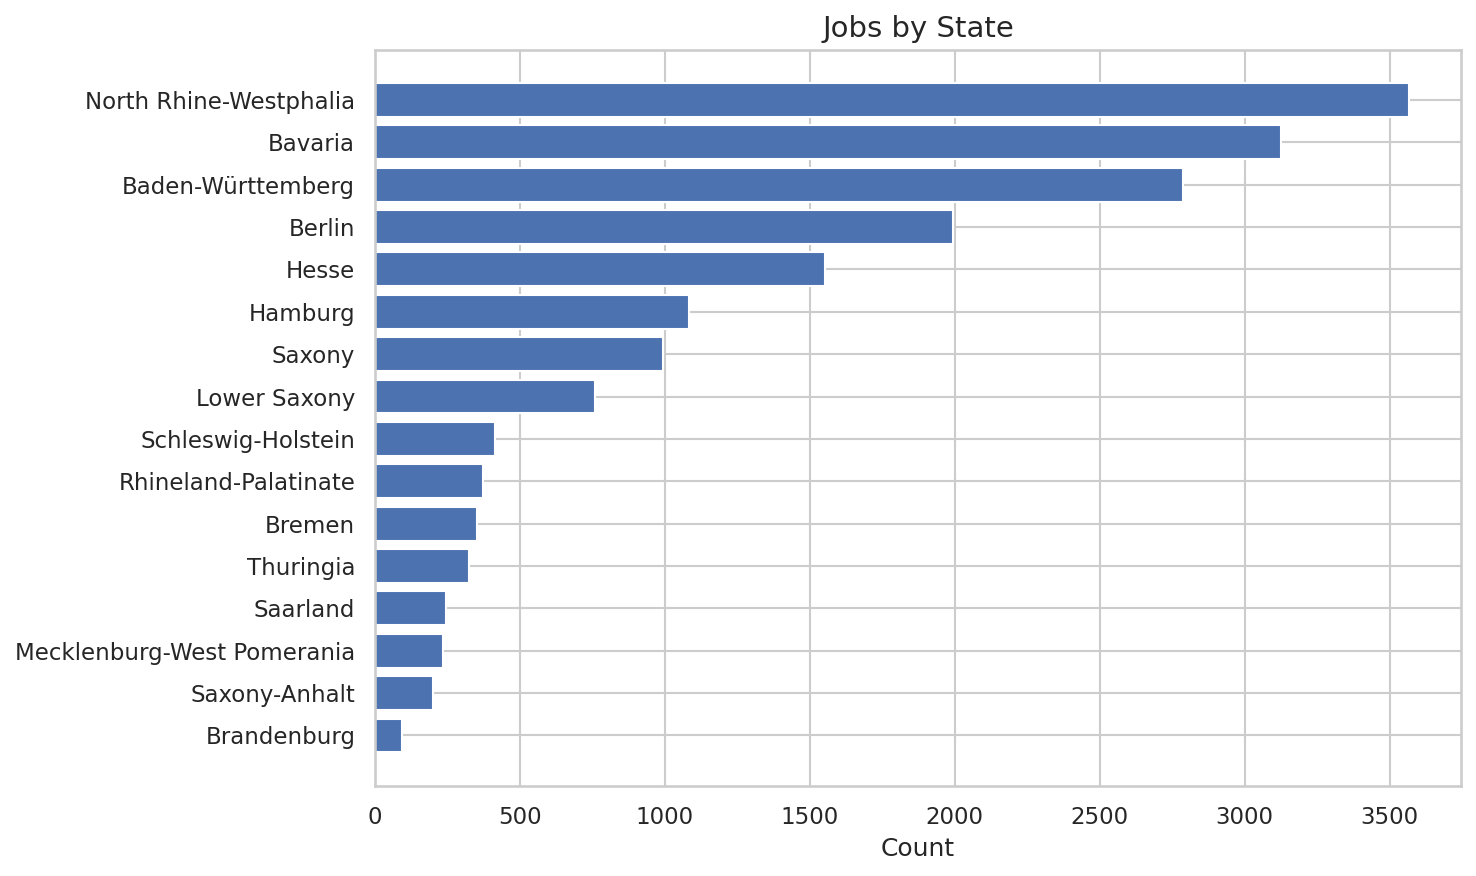

In [15]:
horizontal_bar(
    df[df["state"].notna()]["state"],
    "Jobs by State",
    save_as="04_state.png",
)

## Top 20 Cities

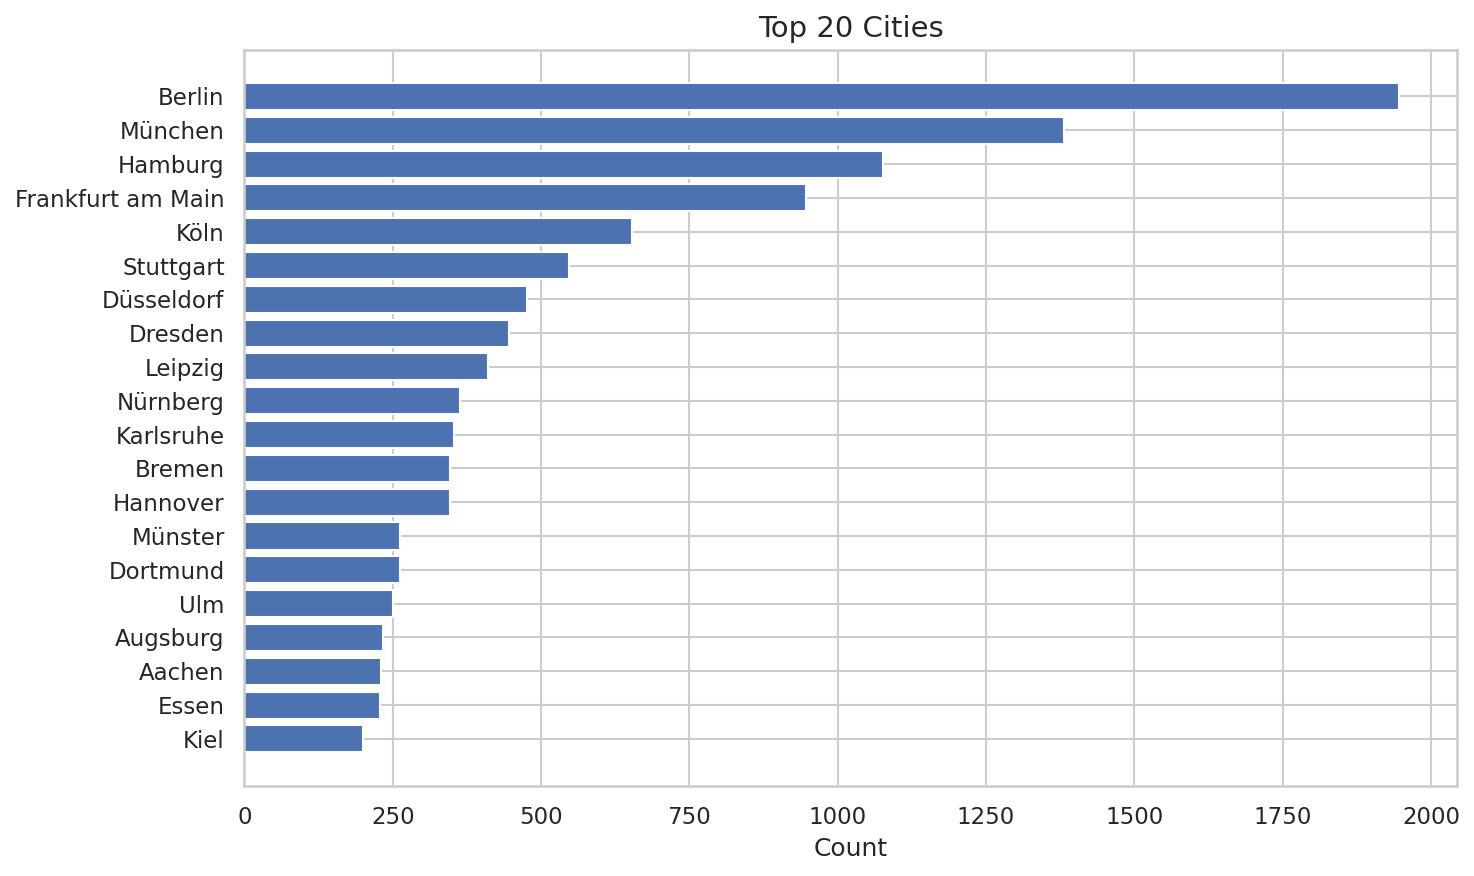

In [16]:
horizontal_bar(
    df[df["city"].notna()]["city"],
    "Top 20 Cities",
    top_n=20,
    save_as="04_cities.png",
)

## City x Job Family Heatmap

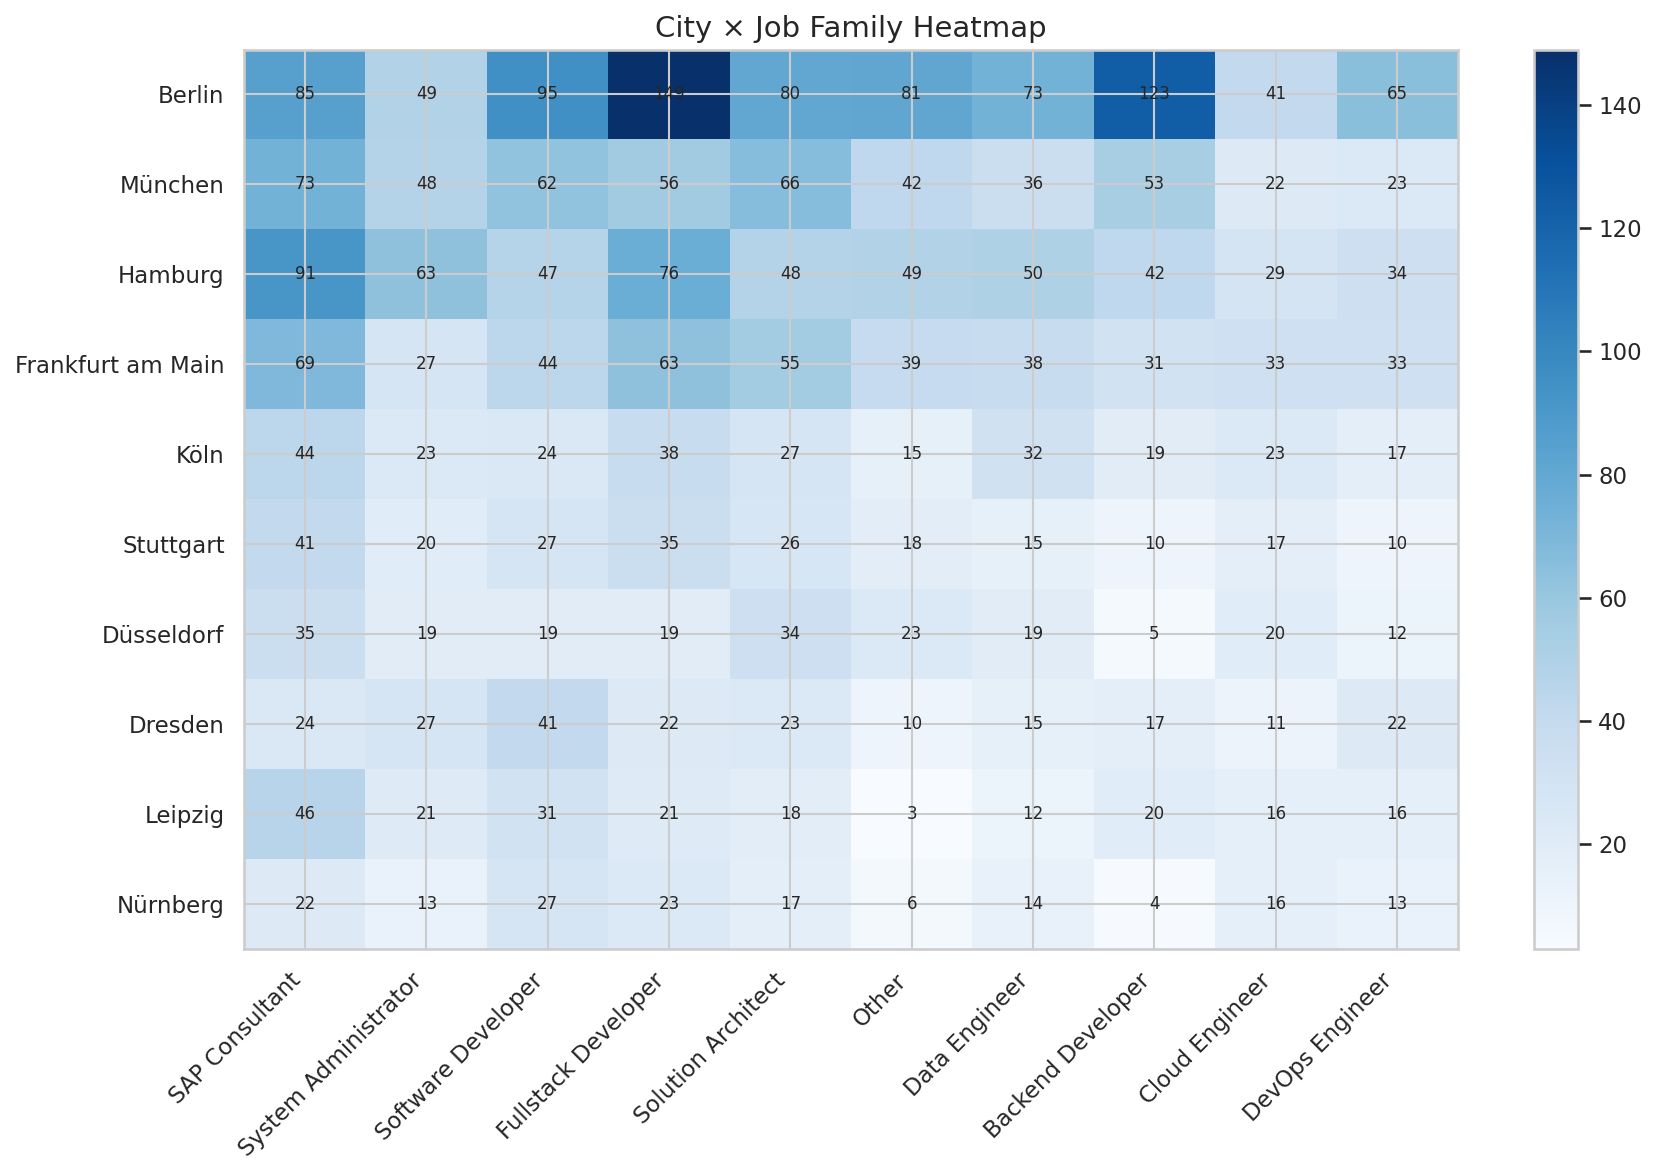

In [17]:
import pandas as pd

top_cities = df[df["city"].notna()]["city"].value_counts().head(10).index
top_families = df["job_family"].value_counts().head(10).index

pivot = (
    df[df["city"].isin(top_cities) & df["job_family"].isin(top_families)]
    .groupby(["city", "job_family"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(index=top_cities, columns=top_families, fill_value=0)
heatmap(pivot, "City × Job Family Heatmap", save_as="04_city_family.png")

## Remote vs On-site by State

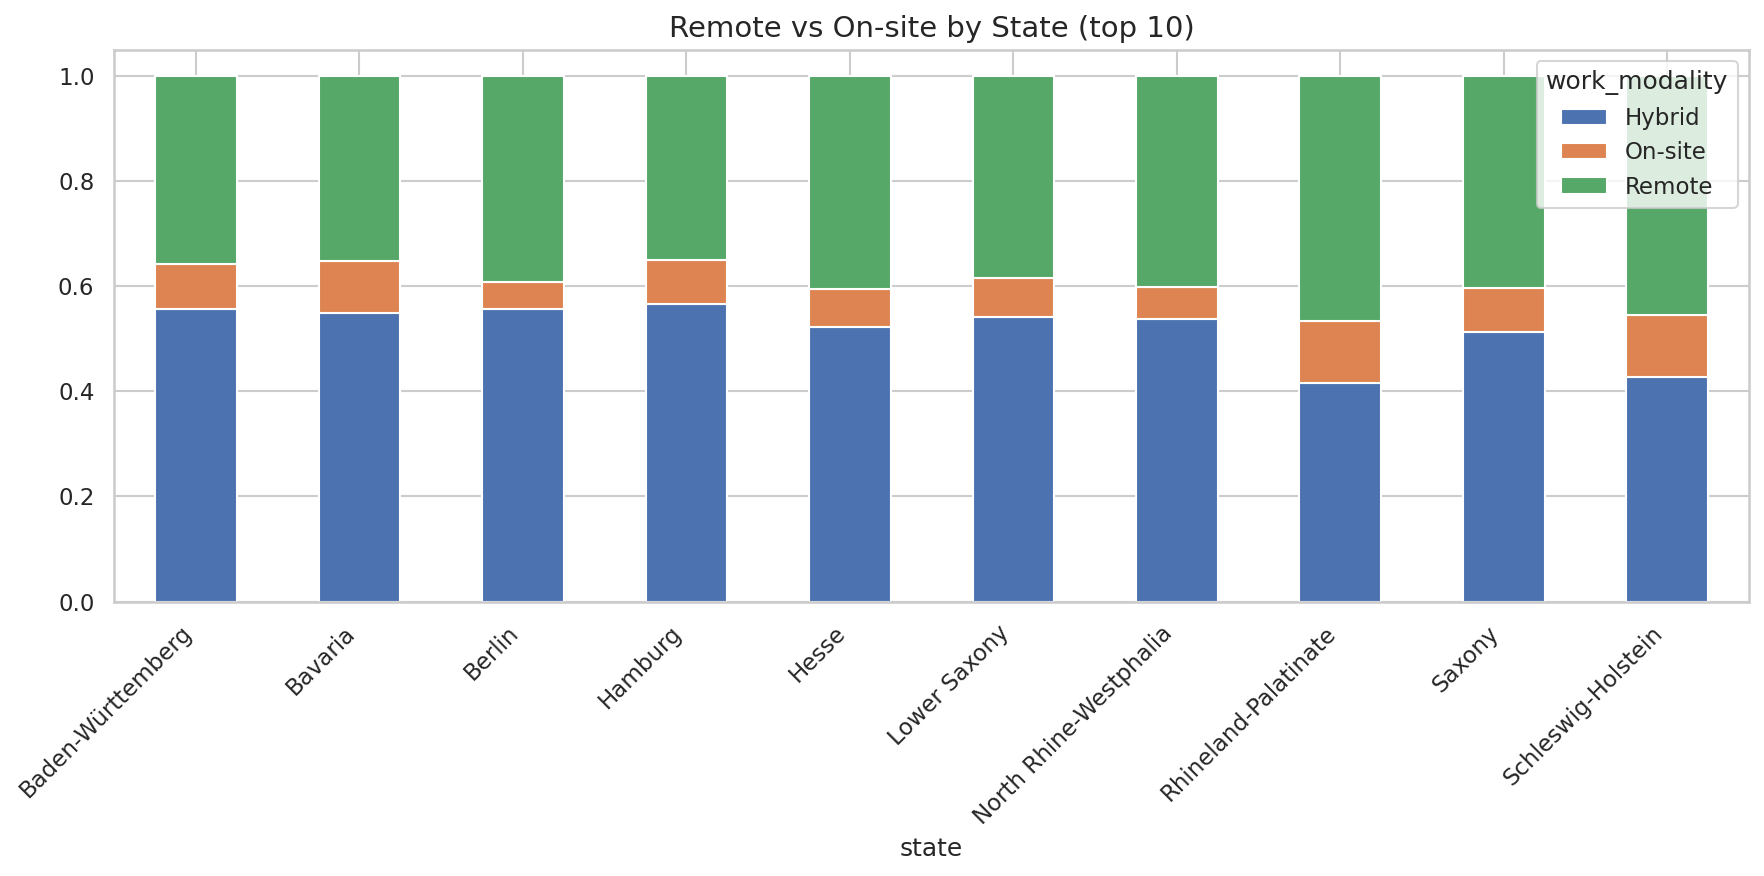

In [18]:
top_states = df[df["state"].notna()]["state"].value_counts().head(10).index
crosstab = pd.crosstab(
    df[df["state"].isin(top_states)]["state"],
    df[df["state"].isin(top_states)]["work_modality"],
    normalize="index",
)
stacked_bar(crosstab, "Remote vs On-site by State (top 10)", save_as="04_remote_state.png")